<a href="https://colab.research.google.com/github/filippozuddas/rst/blob/feature%2Fsignal-realism/notebooks/visualize_signal_types.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RST — Signal Type Visualization

Visual catalogue of **every synthetic signal type** RST injects, for inspecting physical
realism and validating the ON–OFF cadence logic.

What this notebook shows:
1. **ETI spectral profiles** — `gaussian`, `sinc2`, `lorentzian`, `voigt`. Lorentzian/Voigt
   wings model exo-IPM + ISM scattering (Gajjar) and are applied to **ETI only**.
2. **Temporal profiles** — `constant` vs `scintillating` (stochastic red-noise, *no* sine ripple).
3. **RFI zoo** — `linear`, `stationary`, `random_walk`, `scintillating`, `broadband`, `pulsed`.
4. **Full cadence samples** — True (ETI-only / ETI+RFI), False (RFI / hard-false trap / pure background).
5. **Distribution sanity checks** — SNR, drift rate, profile/type counts vs configured weights.

It uses the project's own generators (`SignalGenerator`, `CadenceGenerator`) and plotting helpers
(`plot_spectrogram`, `plot_cadence_panels`), so what you see is exactly what training consumes.

> Plug a **real background plate** into `BACKGROUNDS_PATH` for maximum realism; otherwise the
> notebook falls back to synthetic chi² noise (cleaner for isolating pure signal morphology).

In [7]:
%matplotlib inline
import sys
from pathlib import Path

# Locate the project root (works locally and on Colab)
def find_root():
    for cand in [Path.cwd(), *Path.cwd().parents]:
        if (cand / "src" / "rst_seti").exists():
            return cand
    for cand in [Path("/content/rst"), Path("/content/filippo/rst")]:
        if (cand / "src" / "rst_seti").exists():
            return cand
    raise FileNotFoundError("Could not locate the rst project root (src/rst_seti)")

ROOT = find_root()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))
print("Project root:", ROOT)

Project root: /home/filippo/rst


In [17]:
import collections
from contextlib import contextmanager

import numpy as np
import matplotlib.pyplot as plt
import setigen as stg
from astropy import units as u

from rst_seti.data.signal_generator import (
    SignalGenerator, SignalParams, RFI_TYPES, RFI_TYPE_WEIGHTS,
)
from rst_seti.data.cadence_generator import CadenceGenerator, CadenceParams
from rst_seti.utils.visualization import apply_light_style, plot_spectrogram, plot_cadence_panels

apply_light_style()
SEED = int(np.random.default_rng().integers(0, 2**31 - 1))
print("SEED:", SEED)

_p = SignalParams()
print("setigen          :", stg.__version__)
print("ETI freq profiles:", _p.freq_profiles, _p.freq_profile_weights)
print("ETI time profiles:", _p.time_profiles, _p.time_profile_weights)
print("RFI types        :", tuple(RFI_TYPES))
print("RFI type weights :", tuple(RFI_TYPE_WEIGHTS))
print("df / dt          :", _p.df, "Hz /", _p.dt, "s   (per-ON tchans =", _p.tchans_per_obs, ")")

SEED: 238050365
setigen          : 2.7.0
ETI freq profiles: ('gaussian', 'sinc2', 'lorentzian', 'voigt') (0.55, 0.1, 0.2, 0.15)
ETI time profiles: ('constant', 'scintillating') (0.6, 0.4)
RFI types        : ('linear', 'stationary', 'random_walk', 'scintillating', 'broadband', 'pulsed')
RFI type weights : (0.28, 0.12, 0.17, 0.13, 0.18, 0.12)
df / dt          : 2.7939677238464355 Hz / 18.25361108 s   (per-ON tchans = 16 )


## Background source

`SignalGenerator` injects on top of a background frame: it copies the data and **adds** the
signal, so `injected − background` recovers the *exact, noise-free* signal — used below to draw
clean profile cross-sections.

In [3]:
# Real plate (N, 6, 16, 1024) if available, else synthetic chi-squared noise.
BACKGROUNDS_PATH = ROOT / "data" / "training" / "backgrounds_6GHz.npz"

PARAMS    = SignalParams()
TCHANS_OBS = PARAMS.tchans_per_obs        # 16
N_OBS      = 6
TCHANS     = N_OBS * TCHANS_OBS           # 96
FCHANS     = 1024

def make_synthetic_plate(n=64, seed=SEED):
    rng = np.random.default_rng(seed)
    # chi-squared(2) approximates power-detector (radiometer) noise: positive, right-skewed
    plate = rng.chisquare(df=2, size=(n, N_OBS, TCHANS_OBS, FCHANS)).astype(np.float32)
    return plate * 5.0 + 1.0

if BACKGROUNDS_PATH.exists():
    plate = np.load(BACKGROUNDS_PATH, allow_pickle=True)["backgrounds"]
    SRC_LABEL = f"real backgrounds ({BACKGROUNDS_PATH.name}, N={len(plate)})"
else:
    plate = make_synthetic_plate()
    SRC_LABEL = f"synthetic chi-squared noise (N={len(plate)})"

print("Background source:", SRC_LABEL)
print("Plate shape      :", plate.shape)

def stacked_background(rng):
    """One (96, 1024) stacked background drawn from the plate."""
    obs = plate[rng.integers(0, plate.shape[0])]          # (6, 16, 1024)
    return np.concatenate([obs[i] for i in range(N_OBS)], axis=0).astype(np.float64)

Background source: synthetic chi-squared noise (N=64)
Plate shape      : (64, 6, 16, 1024)


In [4]:
sig = SignalGenerator(PARAMS, seed=SEED)

@contextmanager
def forced(params, **overrides):
    """Temporarily override dataclass fields, restoring them afterwards."""
    old = {k: getattr(params, k) for k in overrides}
    for k, v in overrides.items():
        setattr(params, k, v)
    try:
        yield
    finally:
        for k, v in old.items():
            setattr(params, k, v)

def isolate_signal(injector, bg, **kw):
    """Return (injected, signal_only, info); signal_only = injected - bg is noise-free."""
    injected, info = injector(bg.copy(), **kw)
    return injected, injected - bg, info

## 1 · ETI spectral profiles

Each profile injected as a **zero-drift vertical line** at the band centre, then isolated
noise-free. The log cross-section reveals the **Lorentzian / Voigt scattering wings** that
`gaussian` / `sinc2` lack — these heavy wings are themselves a celestial-source cue
(local RFI is unscattered, so RFI never uses them).

In [5]:
profiles = ['gaussian', 'sinc2', 'lorentzian', 'voigt']
colors    = {'gaussian': '#f59e0b', 'sinc2': '#10b981', 'lorentzian': '#ef4444', 'voigt': '#8b5cf6'}
center    = FCHANS // 2
prof_2d, prof_cross = {}, {}

for k, name in enumerate(profiles):
    bg = stacked_background(np.random.default_rng(SEED + 10 * k))
    with forced(sig.params,
                freq_profiles=(name,),  freq_profile_weights=(1.0,),
                time_profiles=('constant',), time_profile_weights=(1.0,),
                zero_drift_prob=1.0):
        _, signal_only, info = isolate_signal(sig.inject_signal, bg, snr=60.0, start_channel=center)
    prof_2d[name]    = signal_only
    prof_cross[name] = signal_only.mean(axis=0)   # noise-free -> exact f-profile
    print(f"{name:10s} width≈{info['width']:5.1f} Hz   f_profile={info['f_profile']}")

gaussian   width≈  9.1 Hz   f_profile=gaussian
sinc2      width≈  8.9 Hz   f_profile=sinc2
lorentzian width≈  5.2 Hz   f_profile=lorentzian
voigt      width≈  5.5 Hz   f_profile=voigt


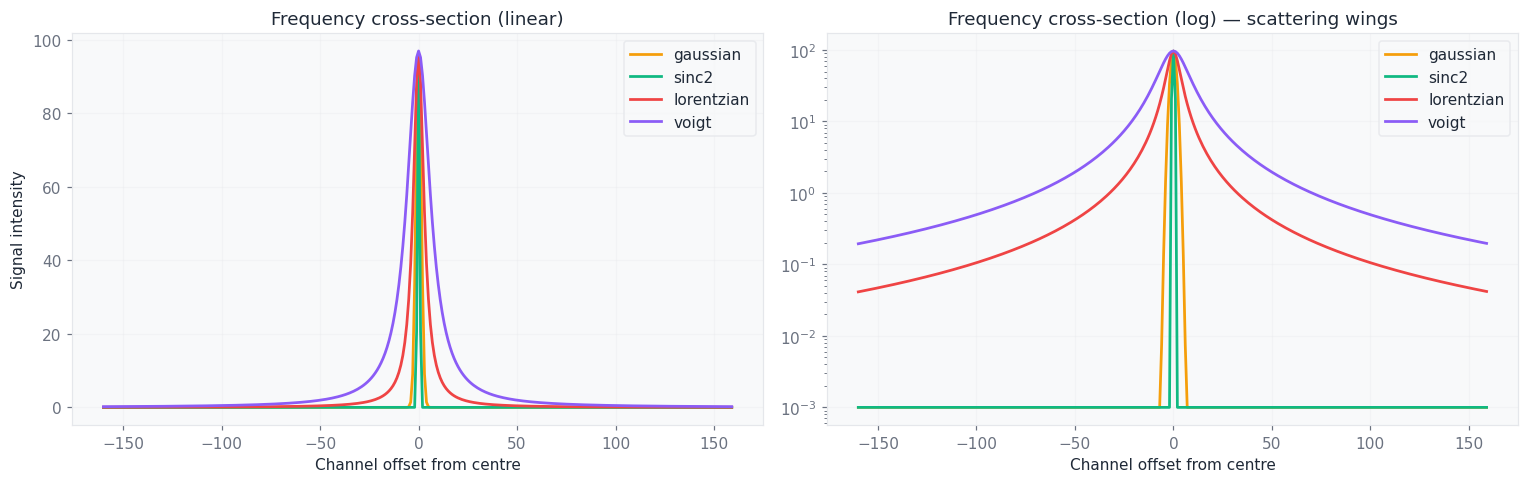

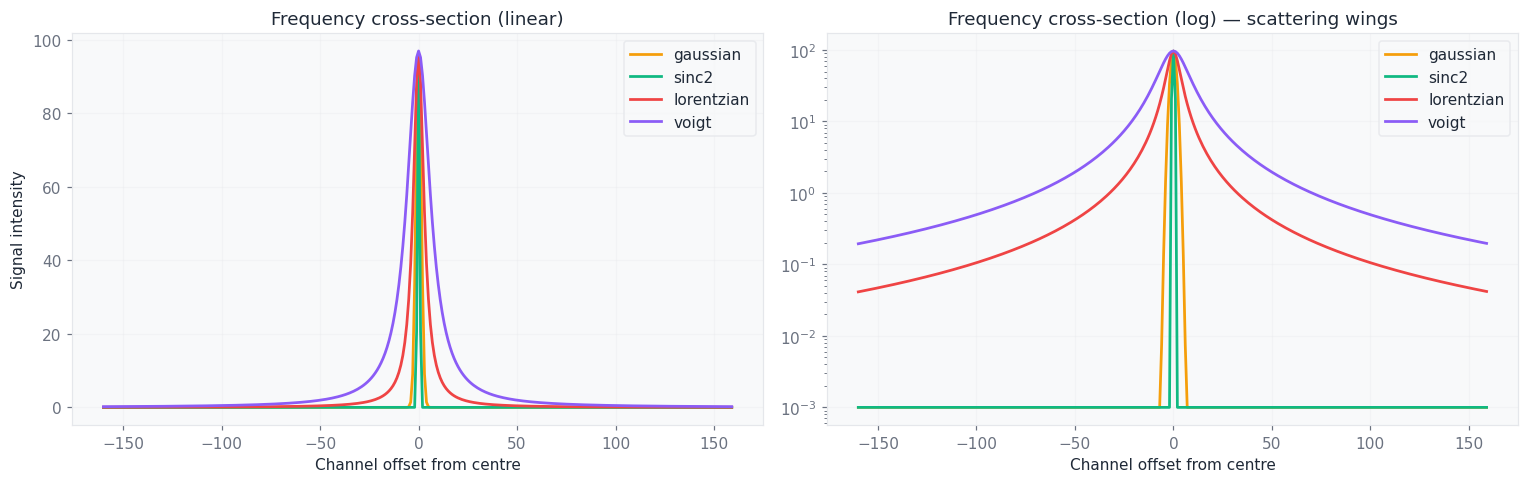

In [8]:
win = 160
off = np.arange(-win, win)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for name in profiles:
    y = prof_cross[name][center - win:center + win]
    axes[0].plot(off, y, label=name, color=colors[name], lw=1.8)
    axes[1].plot(off, np.clip(y, 1e-3, None), label=name, color=colors[name], lw=1.8)
axes[0].set_title("Frequency cross-section (linear)")
axes[1].set_title("Frequency cross-section (log) — scattering wings")
axes[1].set_yscale("log")
for ax in axes:
    ax.set_xlabel("Channel offset from centre"); ax.grid(alpha=.3); ax.legend()
axes[0].set_ylabel("Signal intensity")
plt.tight_layout(); plt.show()

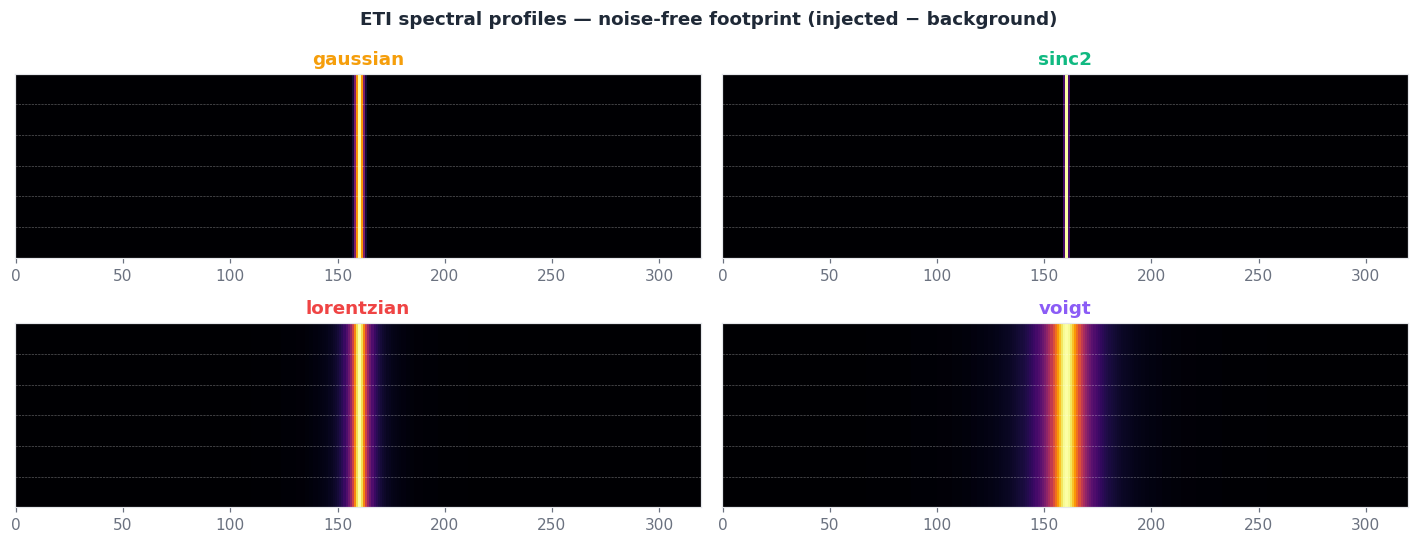

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 5))
for ax, name in zip(axes.flat, profiles):
    ax.imshow(prof_2d[name][:, center - win:center + win], aspect="auto",
              cmap="inferno", origin="upper", interpolation="nearest")
    ax.set_title(name, fontweight="bold", color=colors[name]); ax.set_yticks([])
    for i in range(1, 6):
        ax.axhline(i * 16 - 0.5, color="white", lw=.4, ls="--", alpha=.4)
fig.suptitle("ETI spectral profiles — noise-free footprint (injected − background)",
             fontweight="bold")
plt.tight_layout(); plt.show()

## 2 · Temporal profiles

`constant` vs `scintillating`. Scintillation is now a **stochastic red-noise (AR1) envelope**
with unit mean (so SNR calibration is preserved), replacing the old clean sinusoid — a regular
ripple was a synthetic fingerprint the model could latch onto. Series shown at the signal centre
channel, normalised by their mean; green bands mark the ON scans kept in True samples.

constant       -> t_profile=constant
scintillating  -> t_profile=scintillating_stochastic


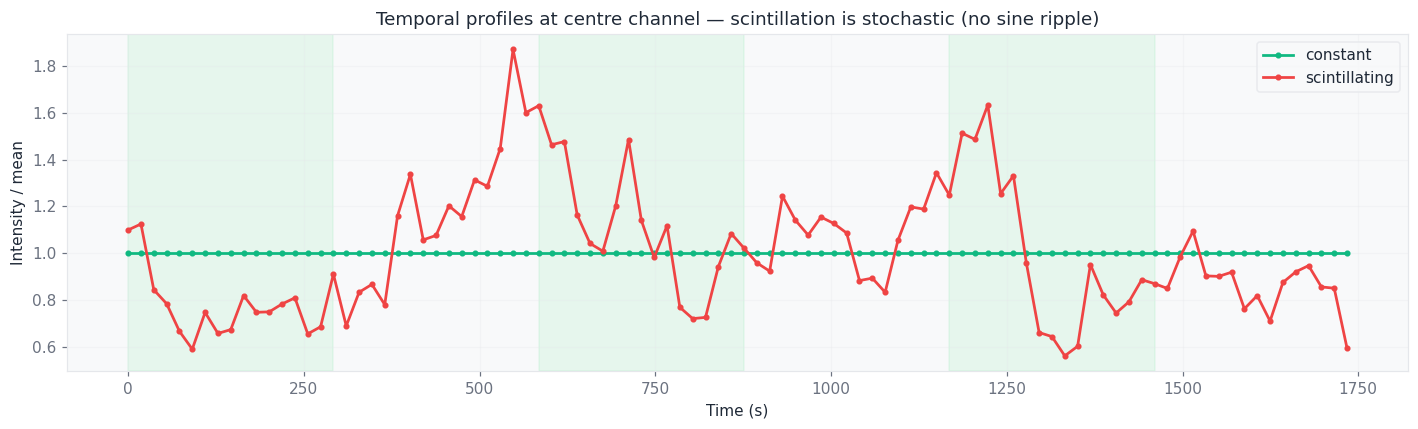

In [10]:
t_series = {}
for k, tname in enumerate(['constant', 'scintillating']):
    bg = stacked_background(np.random.default_rng(SEED + 100 + k))
    with forced(sig.params,
                time_profiles=(tname,), time_profile_weights=(1.0,),
                freq_profiles=('gaussian',), freq_profile_weights=(1.0,),
                zero_drift_prob=1.0):
        _, signal_only, info = isolate_signal(sig.inject_signal, bg, snr=40.0, start_channel=center)
    t_series[tname] = signal_only[:, center]
    print(f"{tname:14s} -> t_profile={info['t_profile']}")

t_axis = np.arange(TCHANS) * PARAMS.dt
fig, ax = plt.subplots(figsize=(13, 4))
for tname, c in [('constant', '#10b981'), ('scintillating', '#ef4444')]:
    s = t_series[tname]
    ax.plot(t_axis, s / s.mean(), label=tname, color=c, lw=1.8, marker='o', ms=3)
for i in (0, 2, 4):  # ON scans
    ax.axvspan(i * TCHANS_OBS * PARAMS.dt, (i + 1) * TCHANS_OBS * PARAMS.dt,
               color='#4ade80', alpha=.10, zorder=0)
ax.set_xlabel("Time (s)"); ax.set_ylabel("Intensity / mean")
ax.set_title("Temporal profiles at centre channel — scintillation is stochastic (no sine ripple)")
ax.grid(alpha=.3); ax.legend(); plt.tight_layout(); plt.show()

## 3 · RFI zoo

Each RFI type injected across the full cadence (RFI has **no ON–OFF preference** — it appears in
every scan, unlike ETI). `broadband` = wide vertical stripe; `pulsed` = periodic on/off bands;
`linear` = drifting diagonal; `stationary` = fixed narrow column; `random_walk` = wandering;
`scintillating` = stochastic intensity.

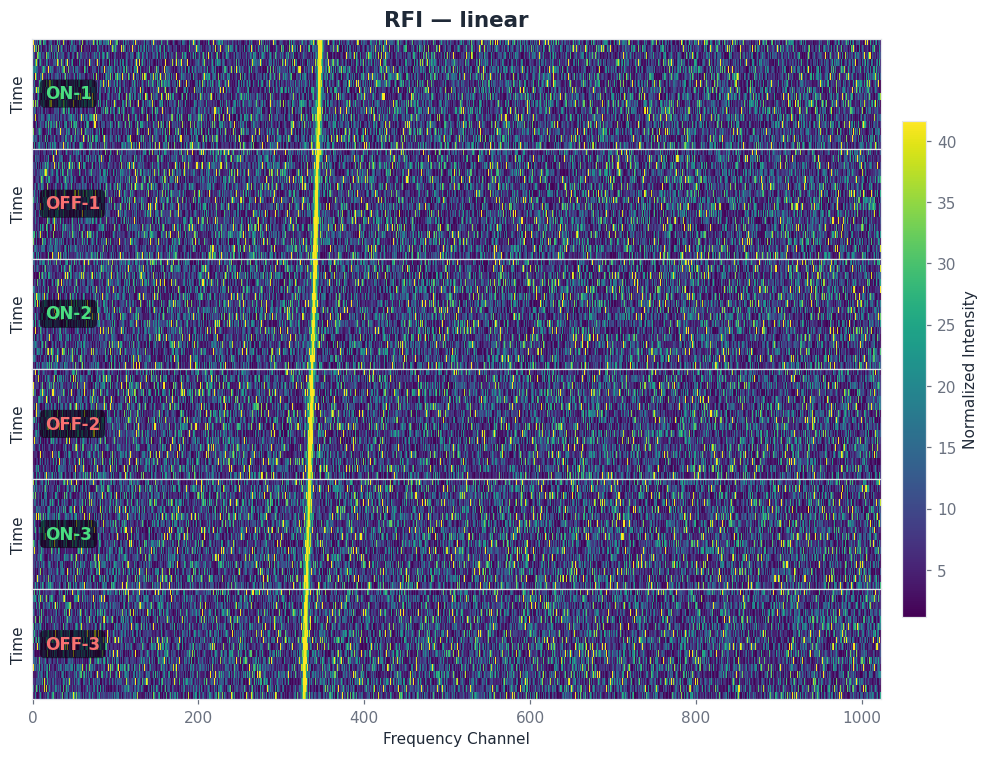

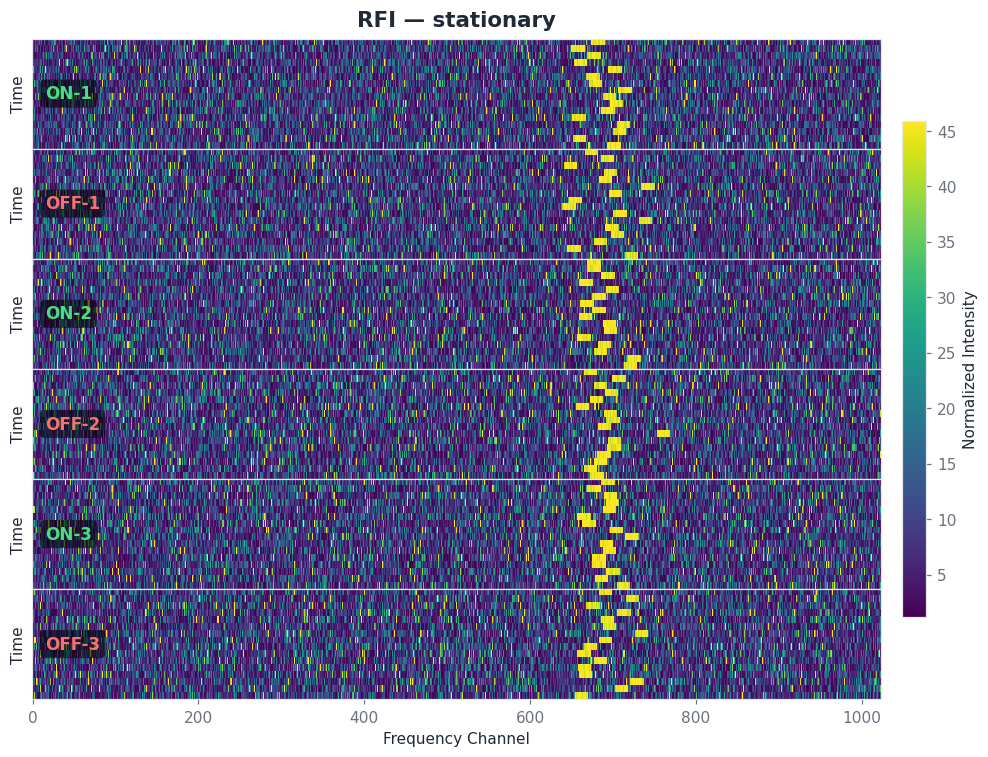

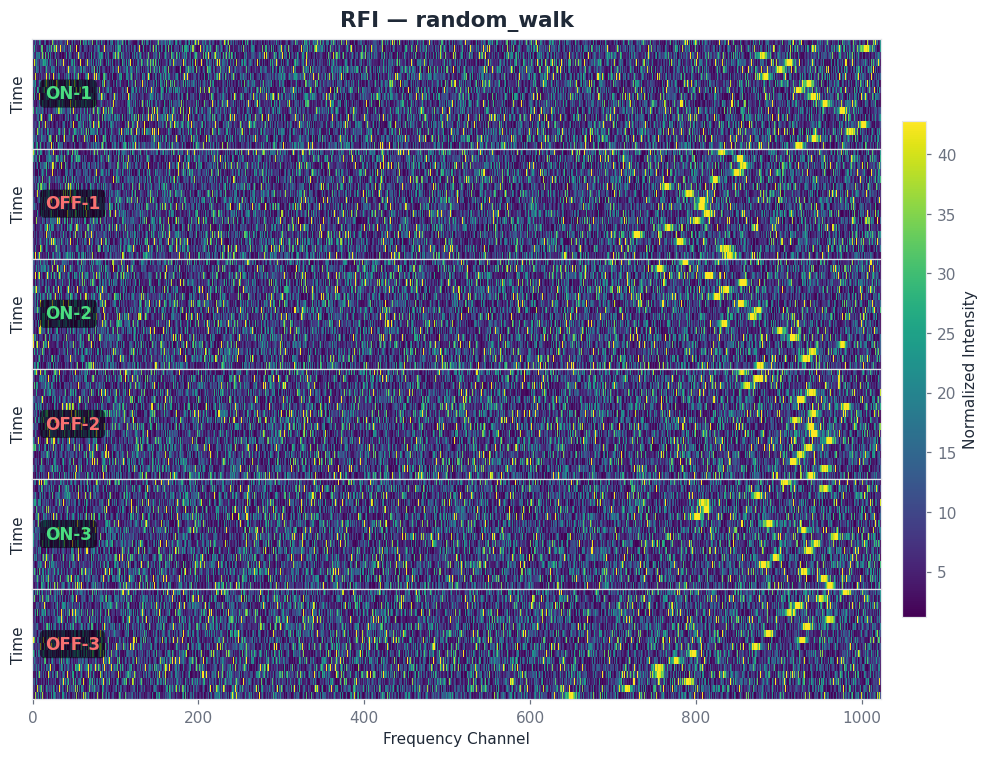

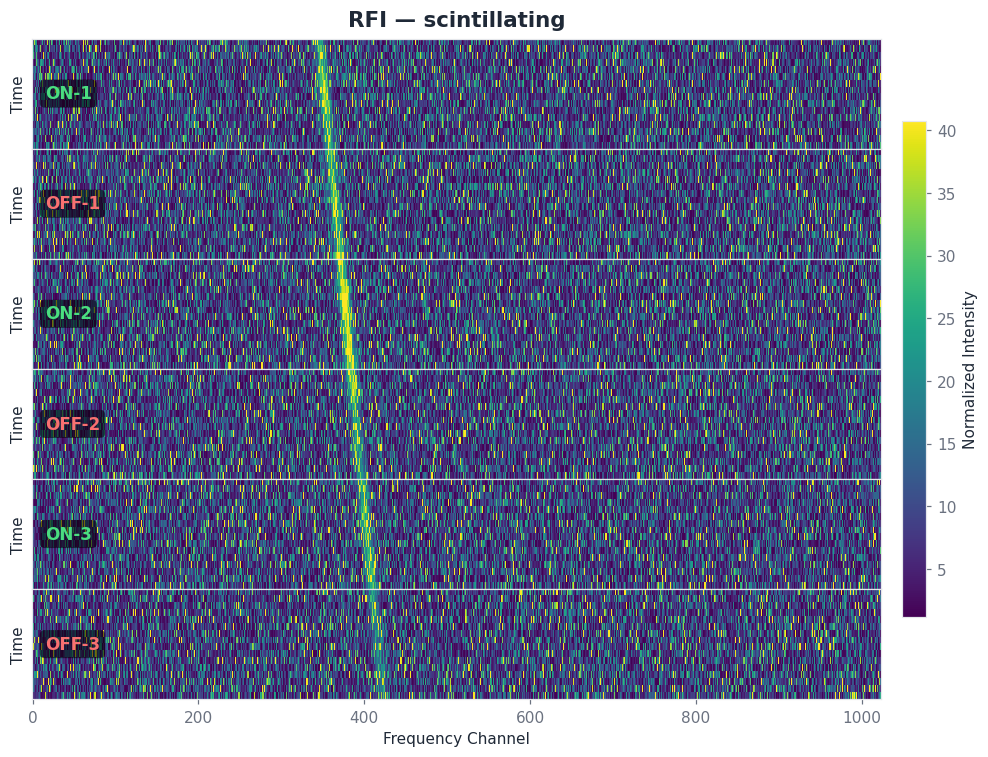

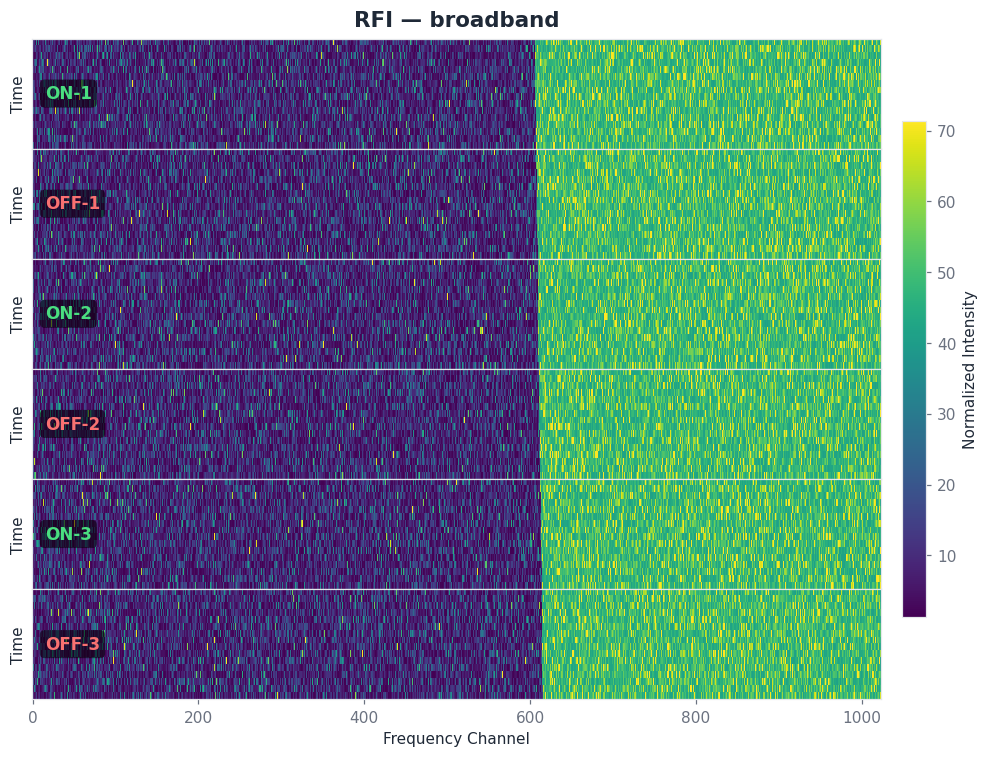

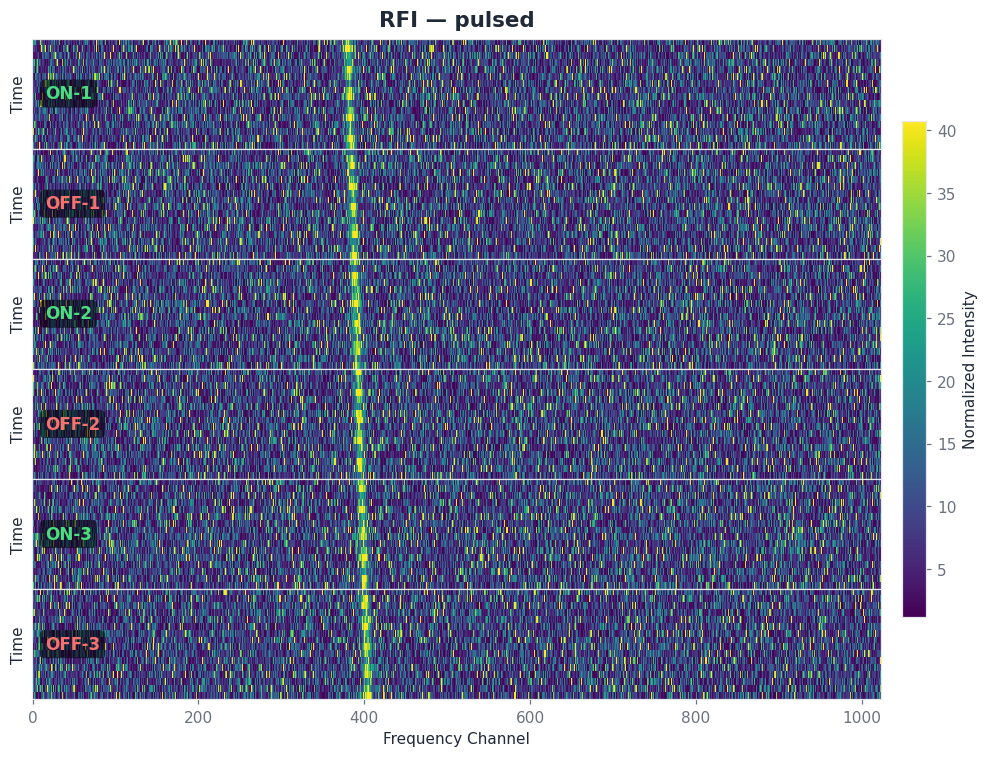

In [18]:
RFI_SNR = 25.0
for k, rtype in enumerate(RFI_TYPES):
    bg = stacked_background(np.random.default_rng(SEED + 200 + k))
    injected, info = sig.inject_rfi_signal(bg.copy(), snr=RFI_SNR, rfi_type=rtype)
    plot_cadence_panels(injected, title=f"RFI — {rtype}", show=True)

## 4 · Full cadence samples

The actual training samples from `CadenceGenerator`, as 6-panel ON/OFF waterfalls.
This is the key validation of the **ON–OFF logic**: ETI lives only in the green ON scans,
while the hard-false trap places an ETI-looking signal in **all six** scans (labelled 0) to
force the model to inspect the OFF scans.

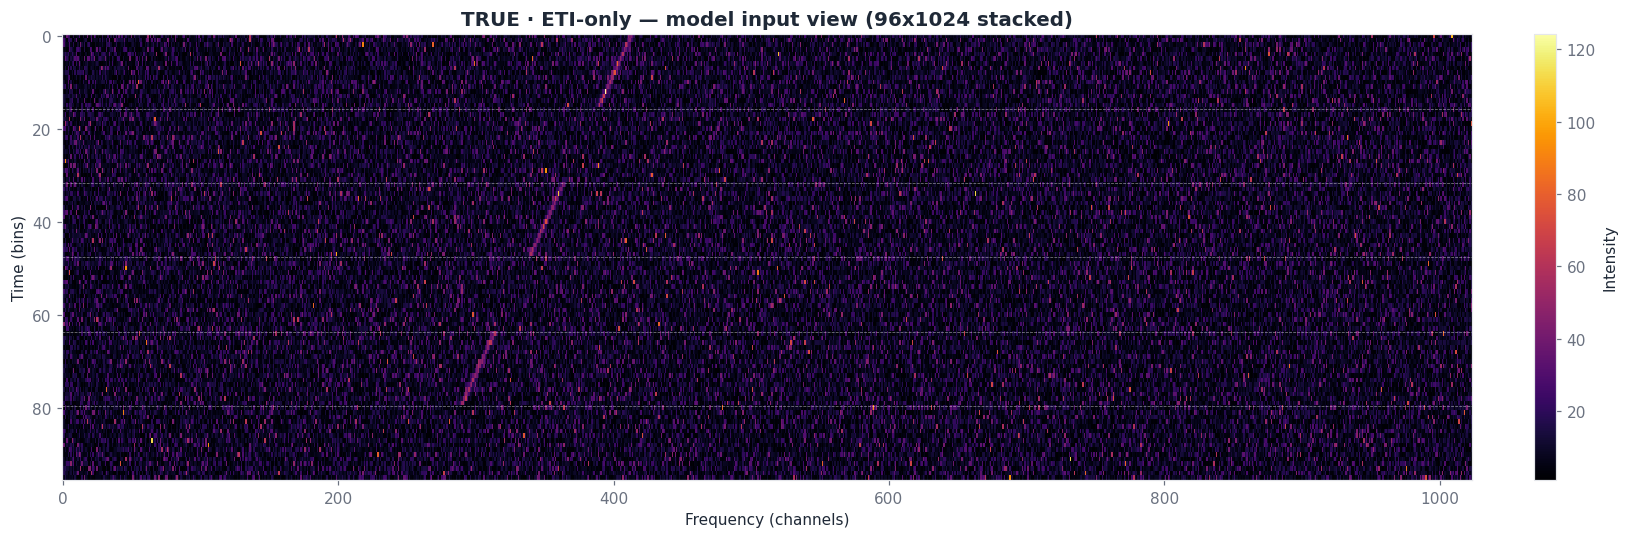

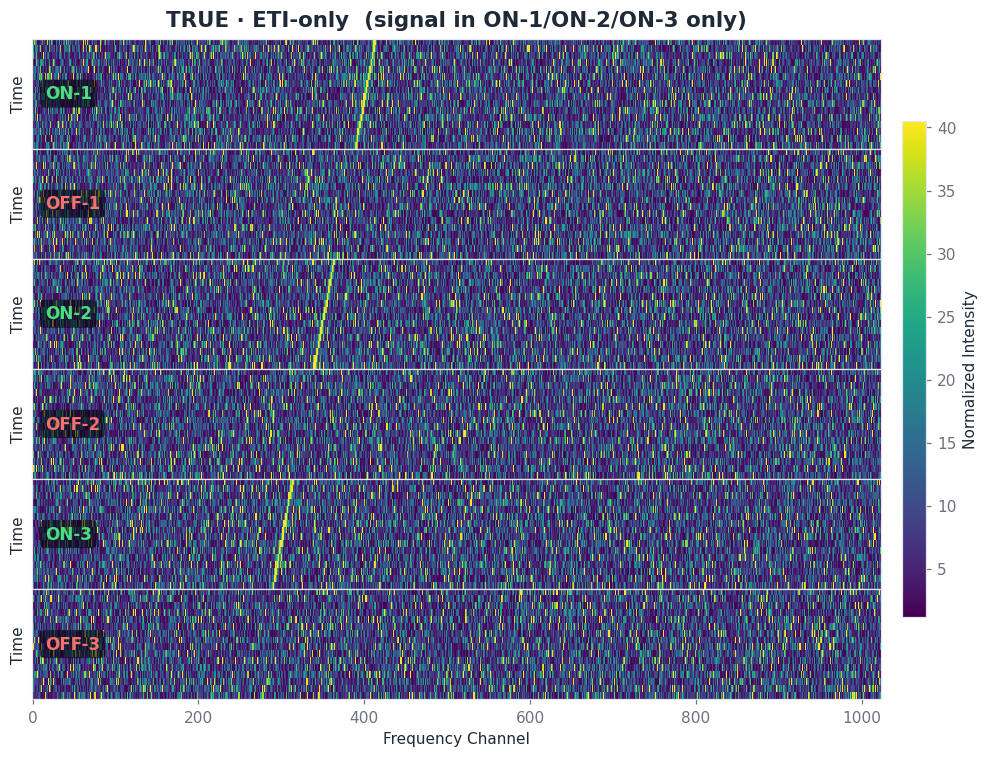

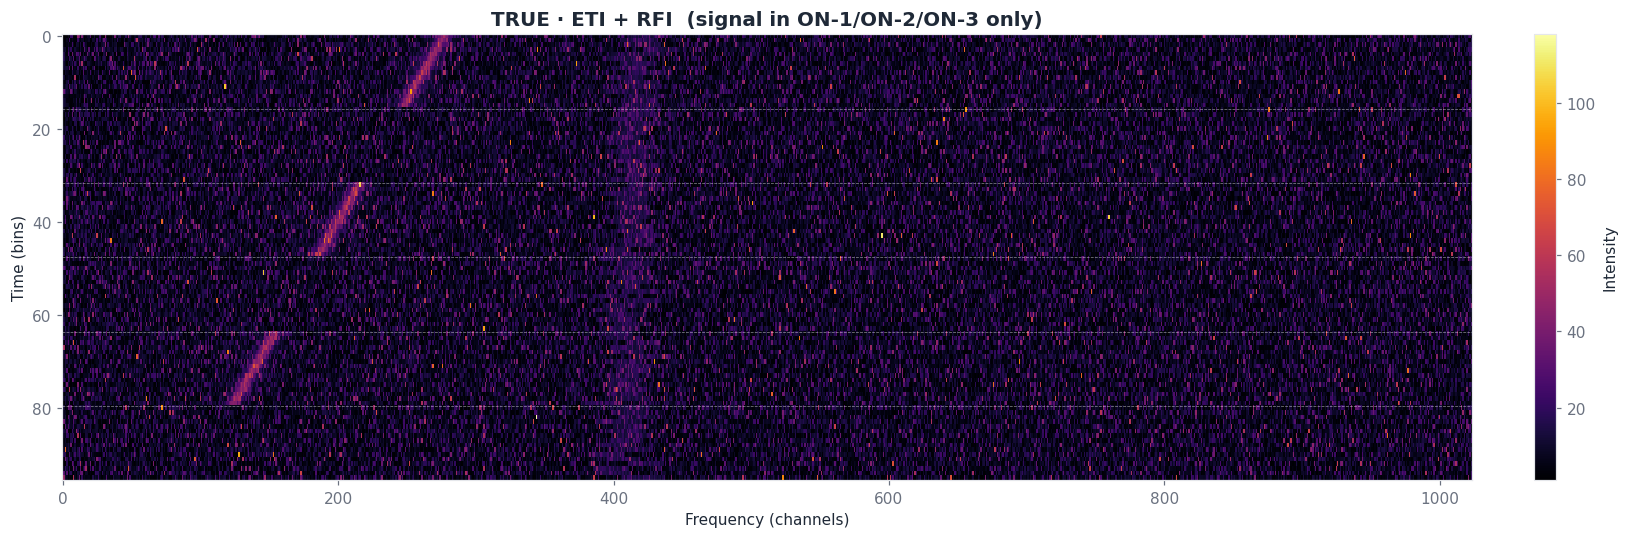

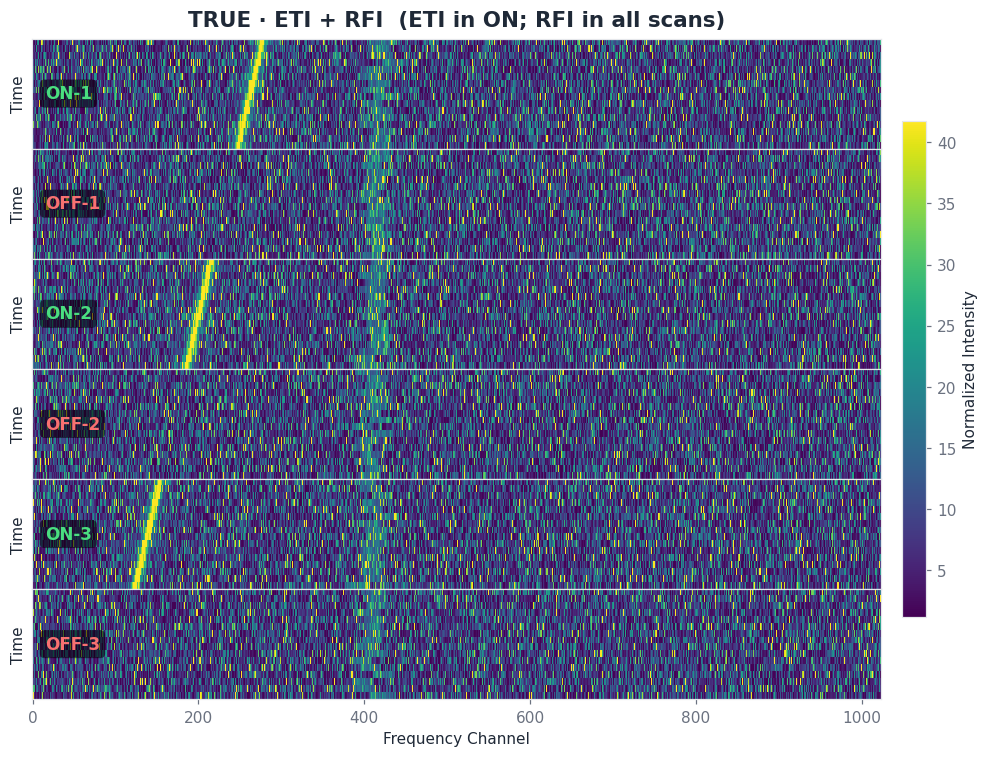

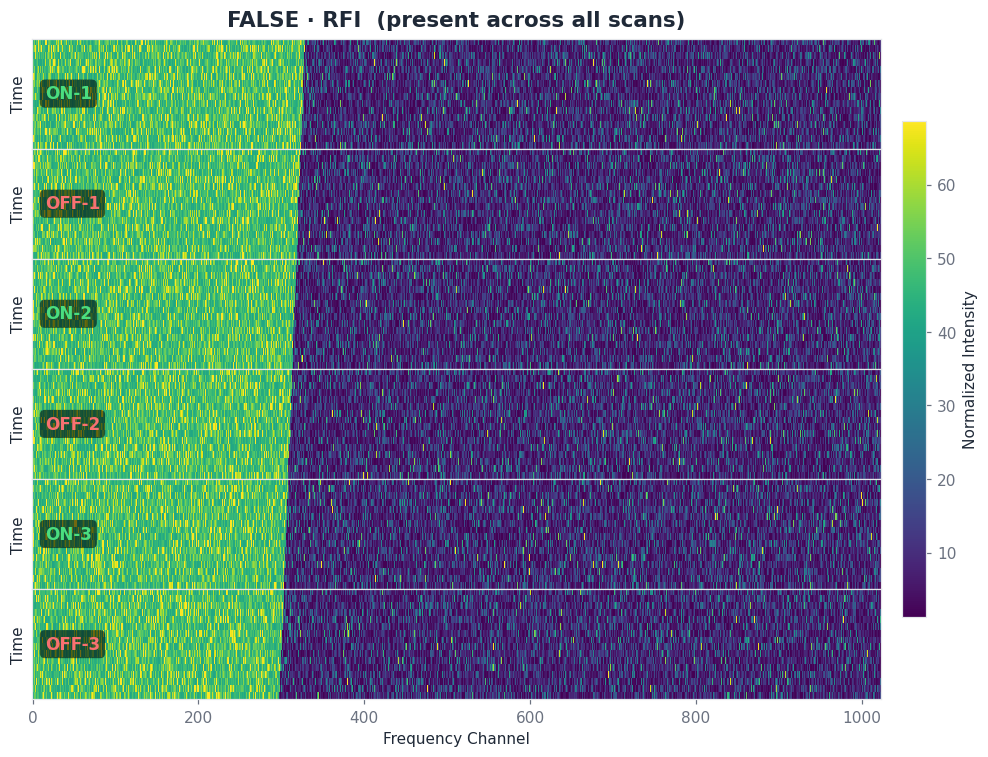

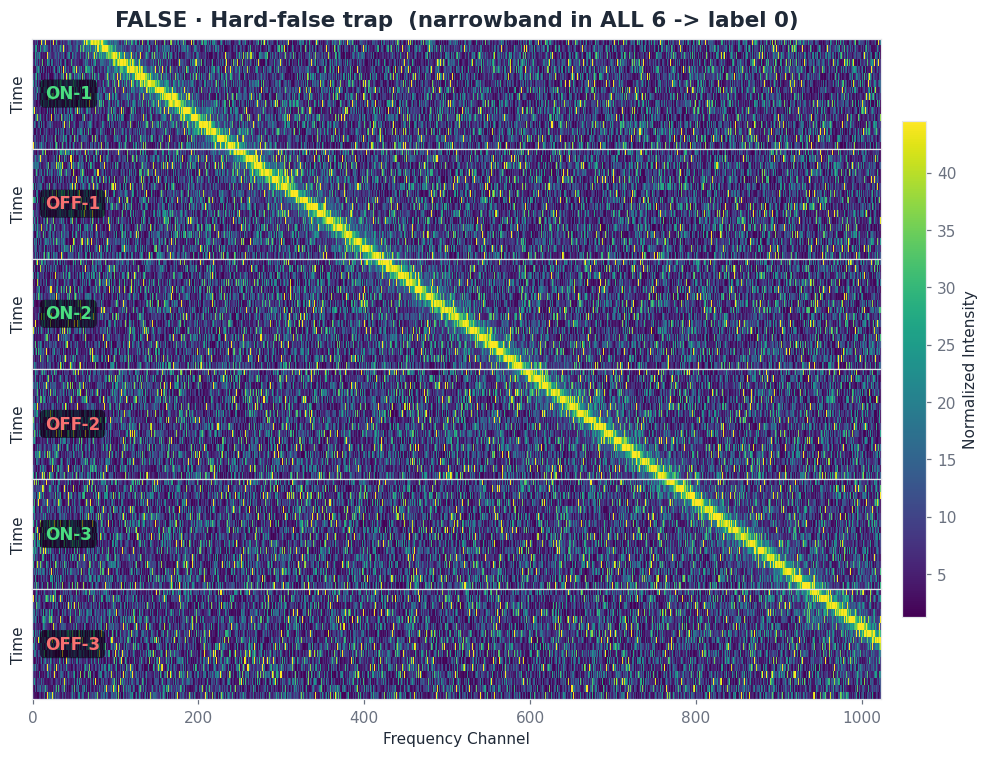

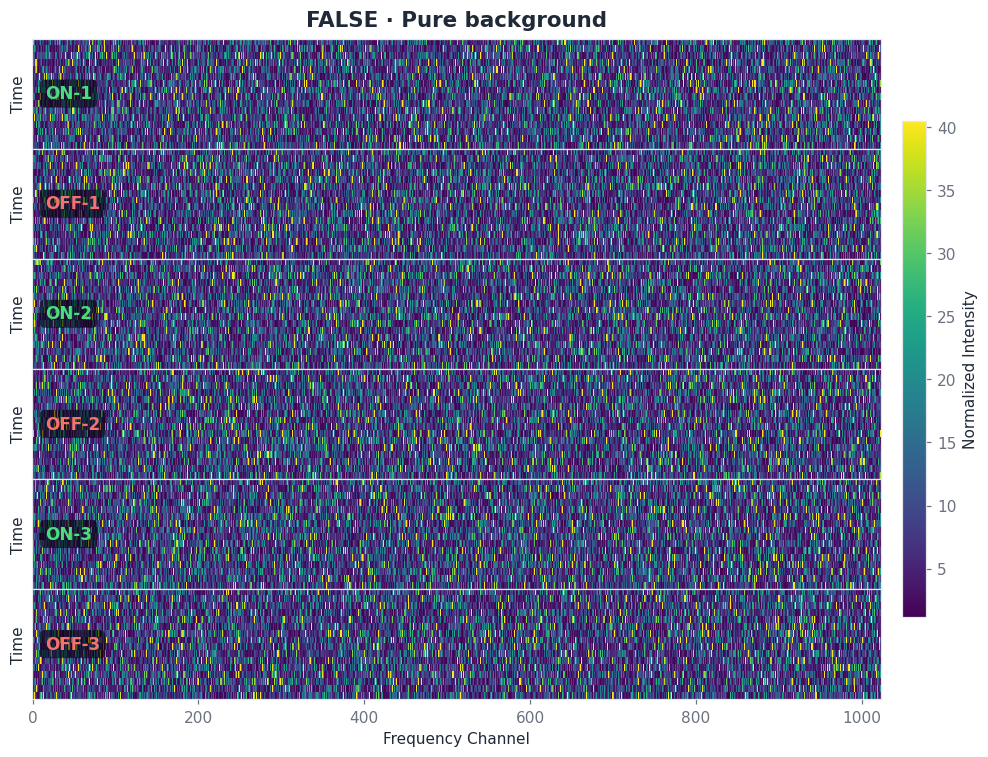

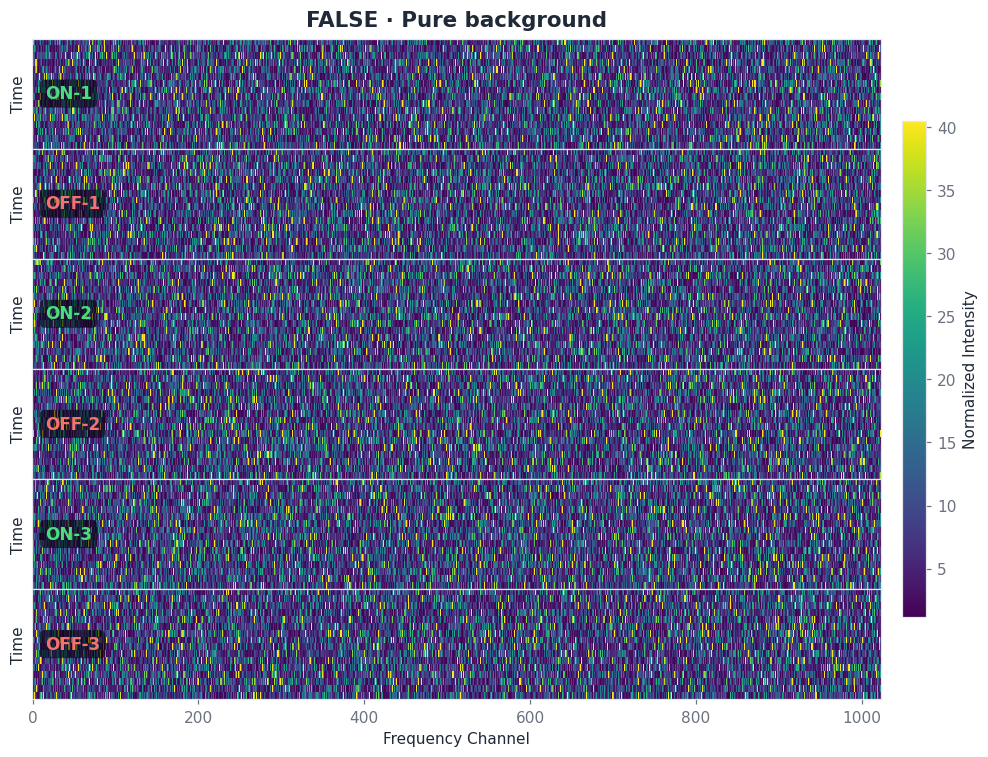

In [19]:
cad = CadenceGenerator(params=CadenceParams(fchans=FCHANS, signal_params=SignalParams()),
                       plate=plate, seed=SEED)
SHOW_SNR = 25.0

c, _ = cad._create_eti_only_sample(snr=SHOW_SNR)
# Same sample, two views: the model-input (96x1024 stacked) and the 6-panel cadence.
plot_spectrogram(c.reshape(TCHANS, FCHANS),
                 title="TRUE · ETI-only — model input view (96x1024 stacked)", show=True)
plot_cadence_panels(c, title="TRUE · ETI-only  (signal in ON-1/ON-2/ON-3 only)", show=True)

c, _ = cad._create_eti_with_rfi_sample(snr=SHOW_SNR)
plot_spectrogram(c.reshape(TCHANS, FCHANS),
                 title="TRUE · ETI + RFI  (signal in ON-1/ON-2/ON-3 only)", show=True)
plot_cadence_panels(c, title="TRUE · ETI + RFI  (ETI in ON; RFI in all scans)", show=True)

with forced(cad.params, hard_false_fraction=0.0, rfi_fraction=1.0):
    c = cad.create_false_sample(snr=SHOW_SNR)
plot_cadence_panels(c, title="FALSE · RFI  (present across all scans)", show=True)

with forced(cad.params, hard_false_fraction=1.0):
    c = cad.create_false_sample(snr=SHOW_SNR)
plot_cadence_panels(c, title="FALSE · Hard-false trap  (narrowband in ALL 6 -> label 0)", show=True)

with forced(cad.params, hard_false_fraction=0.0, rfi_fraction=0.0):
    c = cad.create_false_sample(snr=None)
plot_cadence_panels(c, title="FALSE · Pure background", show=True)

## 5 · Distribution sanity checks

Sample the injectors many times and compare the realised distributions against the configured
weights: SNR is log-uniform and |drift rate| is log-normal (median ≈ 0.3 Hz/s, the Earth+exoplanet
rotational scale at C-band; configurable via `drift_distribution`, `loguniform` also available);
profile/type frequencies should match their weights.

In [ ]:
N = 4000
dsig = SignalGenerator(SignalParams(), seed=SEED + 999)
bg   = stacked_background(np.random.default_rng(0))

eti_snr, eti_dr, eti_fp, eti_tp = [], [], [], []
for _ in range(N):
    _, info = dsig.inject_signal(bg.copy())
    eti_snr.append(info['snr']); eti_dr.append(info['drift_rate'])
    eti_fp.append(info['f_profile']); eti_tp.append(info['t_profile'])

rfi_snr, rfi_ty = [], []
for _ in range(N):
    _, info = dsig.inject_rfi_signal(bg.copy())
    rfi_snr.append(info['snr']); rfi_ty.append(info['rfi_type'])

P = SignalParams()

def bar_vs_weight(ax, labels, counts, expected, title):
    x = np.arange(len(labels)); n = sum(counts.values())
    obs = [counts.get(l, 0) / n for l in labels]
    ax.bar(x - 0.2, obs, 0.4, label='observed', color='#6366f1')
    ax.bar(x + 0.2, expected, 0.4, label='expected', color='#cbd5e1')
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.set_title(title); ax.set_ylabel('fraction'); ax.legend(fontsize=8)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
snr_bins = np.logspace(np.log10(5), np.log10(50), 30)
axes[0, 0].hist(eti_snr, bins=snr_bins, color='#f97316', alpha=.85)
axes[0, 0].set_xscale('log'); axes[0, 0].set_title('ETI SNR (log-uniform [5,50])')
axes[0, 0].set_xlabel('SNR (per-ON visible)')

dr = np.abs(eti_dr); dr = dr[dr > 0]
axes[0, 1].hist(dr, bins=np.logspace(np.log10(0.01), np.log10(dr.max()), 30), color='#3b82f6', alpha=.85)
axes[0, 1].axvline(P.drift_median, color='#1e3a8a', ls='--', lw=1.2, label=f'median {P.drift_median} Hz/s')
axes[0, 1].set_xscale('log')
axes[0, 1].set_title(f'ETI |drift rate| ({P.drift_distribution}, median {P.drift_median} Hz/s)')
axes[0, 1].set_xlabel('Hz/s'); axes[0, 1].legend(fontsize=8)

axes[0, 2].hist(rfi_snr, bins=snr_bins, color='#10b981', alpha=.85)
axes[0, 2].set_xscale('log'); axes[0, 2].set_title('RFI SNR (log-uniform [5,50])')
axes[0, 2].set_xlabel('SNR')

bar_vs_weight(axes[1, 0], list(P.freq_profiles), collections.Counter(eti_fp),
              list(P.freq_profile_weights), 'ETI freq profile')
bar_vs_weight(axes[1, 1], ['constant', 'scintillating_stochastic'], collections.Counter(eti_tp),
              list(P.time_profile_weights), 'ETI time profile')
bar_vs_weight(axes[1, 2], list(P.rfi_types), collections.Counter(rfi_ty),
              list(P.rfi_type_weights), 'RFI type')
plt.tight_layout(); plt.show()

---
**Notes**

- **SNR convention** — the label is the SNR *visible in a single ON scan* (turboSETI-style);
  `_intensity_per_on` rescales by √(96/16)=√6 so "SNR" means the same thing for ETI and RFI.
- **Lorentzian / Voigt** — exo-IPM + ISM scattering wings (recommendation of V. Gajjar, BL/Berkeley);
  ETI-only because terrestrial RFI is unscattered.
- For maximum realism, set `BACKGROUNDS_PATH` to a real plate from `rst-build-backgrounds`.